# Stream YouTube Shorts through YOLO-World

## Goal

Read the cat-and-dog Shorts from `samples/youtube_clips/links.toml`, stream each video, and show YOLO detections inline. The model is limited to the `cat` and `dog` classes.

## Setup

Run this notebook from the project's uv environment. `yt-dlp` resolves each YouTube page to a temporary media URL; the YOLO weights come from this project.

In [1]:
from pathlib import Path
import sys
import tomllib

import cv2
import yt_dlp
from IPython.display import Image, clear_output, display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find the project root")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT / "src"))

with (PROJECT_ROOT / "samples/youtube_clips/links.toml").open("rb") as file:
    clips = tomllib.load(file)["clips"]

clips

[{'title': 'Cat and dog are best friends',
  'url': 'https://www.youtube.com/shorts/r1X0lVMP7us'},
 {'title': 'This cat and dog are best friends',
  'url': 'https://www.youtube.com/shorts/5cUoJTvycL0'},
 {'title': 'Cat comforts a blind dog',
  'url': 'https://www.youtube.com/shorts/mpbuHFT7PfU'},
 {'title': 'Dog and kitten become best friends',
  'url': 'https://www.youtube.com/shorts/7nUbsCDOFhI'}]

## Load the model

In [2]:
from detect_objects.models.yolo_world_module import YOLO_World_Manager

manager = YOLO_World_Manager(confidence=0.45)
manager.load()
manager.set_classes(["cat", "dog"])
print(f"Running on {manager.device_name}")

model path:/Users/kafka/Github_/odia-project/detect_objects/model_artifacts/vision/yolov8s-worldv2.pt

manager initialized..

YOLO-World 모델 로딩: /Users/kafka/Github_/odia-project/detect_objects/model_artifacts/vision/yolov8s-worldv2.pt
추론 장치: mps (Apple Metal Performance Shaders)


Running on Apple Metal Performance Shaders


## Stream and detect

In [3]:
def resolve_stream(page_url: str) -> tuple[str, str]:
    options = {
        "quiet": True,
        "no_warnings": True,
        "noplaylist": True,
        "format": "best[ext=mp4]/best",
    }
    with yt_dlp.YoutubeDL(options) as downloader:
        info = downloader.extract_info(page_url, download=False)
    return info["title"], info["url"]


def draw_detections(frame, boxes, names):
    annotated = frame.copy()
    for xyxy, confidence, class_id in zip(boxes.xyxy, boxes.conf, boxes.cls):
        x1, y1, x2, y2 = map(int, xyxy.tolist())
        label = f"{names[int(class_id)]} {float(confidence):.2f}"
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            annotated,
            label,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
        )
    return annotated


def show_frame(frame):
    ok, encoded = cv2.imencode(".jpg", frame)
    if ok:
        display(Image(data=encoded.tobytes()))

🐶🐱 Inspiring Story of Dog and Kitten Becoming Best Friends 🐾✨ #cutedog #cutekitty  #dogandkitten


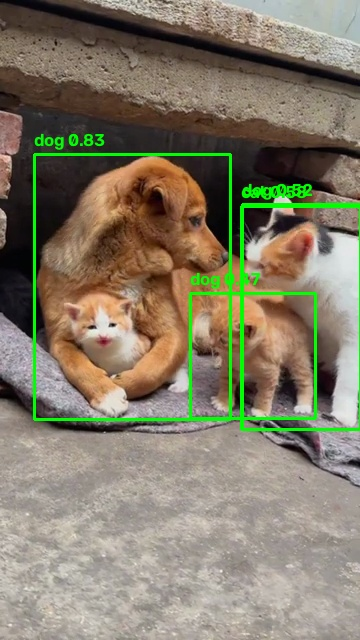

YOLO-World 모델 자원을 해제했습니다.
Processed 4/4 clips


In [4]:
PREVIEW_SECONDS = 5
INFER_EVERY_N_FRAMES = 10
processed_titles = []

try:
    for clip in clips:
        title, stream_url = resolve_stream(clip["url"])
        capture = cv2.VideoCapture(stream_url)
        if not capture.isOpened():
            print(f"Could not open: {title}")
            continue

        fps = capture.get(cv2.CAP_PROP_FPS) or 30
        max_frames = int(PREVIEW_SECONDS * fps)

        try:
            for frame_number in range(max_frames):
                ok, frame = capture.read()
                if not ok:
                    break
                if frame_number % INFER_EVERY_N_FRAMES:
                    continue

                boxes, names = manager.predict(frame)
                annotated = draw_detections(frame, boxes, names)
                clear_output(wait=True)
                print(title)
                show_frame(annotated)
        finally:
            capture.release()
        processed_titles.append(title)
finally:
    manager.close()

print(f"Processed {len(processed_titles)}/{len(clips)} clips")

## Checks

- Each link is resolved immediately before playback because YouTube media URLs expire.
- Green boxes should be labeled only `cat` or `dog`.
- Increase `PREVIEW_SECONDS` or decrease `INFER_EVERY_N_FRAMES` for a longer or denser preview.